In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
N_CLASSES=21

def _dilinear_kernel(in_ch,out_ch,k):
    factor=(k+1)//2
    center=factor-1 if k%2==1 else factor-0.5
    og_y=torch.arange(k).reshape(-1,1)
    og_x=torch.arange(k).reshape(1,-1)
    filt=(1-torch.abs(og_y-center)/factor)*(1-torch.abs(og_x-center)/factor)
    weight=torch.zeros((in_ch,out_ch,k,k))
    for i in  range(in_ch):
        for j in range(out_ch):
            weight[i,j]=filt
    return weight

class FCN8s(nn.Module):
    def __init__(self,n_class,use_interpolate=True):
        super().__init__()
        self.n_class=n_class
        self.use_interpolate=use_interpolate

        # 인코더        
        self.block1=nn.Sequential(
            nn.Conv2d(3,64,3,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64,64,3,padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2)
        )
        self.block2=nn.Sequential(
            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128,128,3,padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2) # /4
        )
        self.block3=nn.Sequential(
            nn.Conv2d(128,256,3,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256,256,3,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256,256,3,padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2) # /8
        )
        self.block4=nn.Sequential(
            nn.Conv2d(256,512,3,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512,512,3,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512,512,3,padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2) # /16
        )
        self.block5=nn.Sequential(
            nn.Conv2d(512,512,3,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512,512,3,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512,512,3,padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2) # /32
        )
        self.conv6=nn.Sequential(
            nn.Conv2d(512,4096,3,padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.5) # /32
        )
        self.conv7=nn.Sequential(
            nn.Conv2d(4096,4096,3,padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.5) # /32
        )
        self.score_fr=nn.Conv2d(4096,n_class,kernel_size=1)
        self.score_pool4=nn.Conv2d(512,n_class,kernel_size=1)
        self.score_pool3=nn.Conv2d(256,n_class,kernel_size=1)

        # 디코더
        self.upscore2=nn.ConvTranspose2d(n_class,n_class,kernel_size=4,stride=2,padding=1,bias=False) # 전치 컨볼루션
        self.upscore_pool4=nn.ConvTranspose2d(n_class,n_class,kernel_size=4,stride=2,padding=1,bias=False) # 전치 컨볼루션
        self.upscore8=nn.ConvTranspose2d(n_class,n_class,kernel_size=16,stride=8,padding=4,bias=False) # 전치 컨볼루션

        self._init_weights()

    def _init_weights(self): # 레이어 계층 초기화
        # 컨볼루션층 초기화
        for m in self.modules():
            if isinstance(m,nn.Conv2d):
                nn.init.kaiming_normal_(m.weight,mode='fan_out',nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

        self.upscore2.weight.data.copy_(_dilinear_kernel(self.n_class,self.n_class,4))
        self.upscore_pool4.weight.data.copy_(_dilinear_kernel(self.n_class,self.n_class,4))
        self.upscore8.weight.data.copy_(_dilinear_kernel(self.n_class,self.n_class,16))

    def forward(self,x):
        H,W=x.shape[-2:]
        # 인코더층
        h=self.block1(x)
        h=self.block2(h)
        pool3=self.block3(h)
        pool4=self.block4(pool3)
        pool5=self.block5(pool4)

        # 분류층(클래스층)
        h=self.conv6(pool5)
        h=self.conv7(h)
        score_fr=self.score_fr(h) # /32

        # 디코더층1 /16
        upscore2=self.upscore2(score_fr) # /16
        score_pool4=self.score_pool4(pool4) # /16
        fuse_pool4=upscore2+score_pool4

        # 디코더층2 /8
        upscore_pool4=self.upscore_pool4(fuse_pool4) # /8
        score_pool3=self.score_pool3(pool3) # /8
        fuse_pool3=upscore_pool4+score_pool3

        # 디코더층3 /1(원래 사이즈)
        out=self.upscore8(fuse_pool3) # (B,C,H,W)
        
        # 해상도 오차 조정(입력 크기 차이성) -> 간섭 많을수록 왜곡 발생 多
        if self.use_interpolate and (out.shape[-2:]!=(H,W)):
            out=F.interpolate(out,size=(H,W),mode='bilinear',align_corners=False)
        return {'out':out}

In [10]:
m=FCN8s(n_class=N_CLASSES)

In [11]:
from torchvision import models
m1=models.segmentation.fcn_resnet50(
    weights=None, # 랜덤 초기화
    weights_backbone=None, # 백본 가중치 랜덤 초기화
    num_classes=N_CLASSES
)

In [12]:
weights=models.segmentation.FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
m2=models.segmentation.fcn_resnet50(weights=weights,num_classes=N_CLASSES)

Downloading: "https://download.pytorch.org/models/fcn_resnet50_coco-1167a1af.pth" to C:\Users\ksa/.cache\torch\hub\checkpoints\fcn_resnet50_coco-1167a1af.pth


100%|██████████| 135M/135M [00:02<00:00, 49.0MB/s] 


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import functional as TF
import os

IMG_SIZE=512
IGNORE_INDEX=255
VOC_CLASSES=[
    "background",
    "aeroplane","bicycle","bird","boat",
    "bottle","bus","car","cat","chair",
    "cow","diningtable","dog","horse","motorbike",
    "person","pottedplant","sheep","sofa","train","tvmonitor"
]
PAL = np.array([
    [0,0,0],[128,0,0],[0,128,0],[128,128,0],[0,0,128],
    [128,0,128],[0,128,128],[128,128,128],[64,0,0],[192,0,0],
    [64,128,0],[192,128,0],[64,0,128],[192,0,128],[64,128,128],
    [192,128,128],[0,64,0],[128,64,0],[0,192,0],[128,192,0],[0,64,128]
], dtype=np.uint8)

def denorm(img):
    mean=torch.tensor([0.485,0.456,0.406])[:,None,None]
    std=torch.tensor([0.229,0.224,0.225])[:,None,None]
    return (img*std+mean).clamp(0,1)

def colorize_mask(mask_np):
    m=mask_np.copy()
    m[m==IGNORE_INDEX]==0
    return PAL[m]

def preprocess_image_for_infer(img_path):
    img=Image.open(img_path).convert('RGB')
    img_r=TF.resize(img,(IMG_SIZE,IMG_SIZE))
    t=TF.to_tensor(img_r)
    TF.normalize(t,[0.485,0.456,0.406],[0.229,0.224,0.225])
    return img,t.unsqueeze(0)

def annotate_classes_on_segments(ax,pred_mask_resized,classes,ignore_index=255,bg_color='white'):
    uniq=np.unique(pred_mask_resized)
    uniq=uniq[uniq!=ignore_index]
    for cls_id in uniq:
        if not (0<=cls_id<len(classes)):
            continue
        ys,yx=np.where(pred_mask_resized==cls_id)
        if ys.size==0:
            continue
        cy,cx=float(ys.mean()),float(yx.mean())
        ax.text(cx,cy,classes[cls_id],ha='center',va='center',fontsize=11,color='black',
                bbox=dict(facecolor=bg_color,alpha=0.6,edgecolor='none',boxstyle='round,pad=0.2'))

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
@torch.no_grad()        
def infer_one_image_pretrained(img_path,save_path=None,overlay=True,alpha=0.6):
    weights=models.segmentation.FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
    m=models.segmentation.fcn_resnet50(weights=weights,num_classes=N_CLASSES).to(device)
    m.eval()
    
    pil_oj,t=preprocess_image_for_infer(img_path)
    t=t.to(device)
    out=m(t)['out'] # (1,21,512,512)
    pred_512=out.argmax(1)[0].cpu().numpy() # (512,512)
    vis_mask=colorize_mask(pred_512) # (512,512,3)
    if overlay:
        den=(denorm(t[0]).cpu().numpy().transpose(1,2,0)*255).astype(np.uint8)
        vis_512=(den*(1-alpha)+vis_mask*alpha).astype(np.uint8)
    else:
        vis_512=vis_mask
    out_vis_pil=Image.fromarray(vis_512).resize(pil_oj.size,resample=Image.NEAREST)
    pred_orig=np.array(Image.fromarray(pred_512.astype(np.uint8)).resize(pil_oj.size,resample=Image.NEAREST))
    
    plt.figure(figsize=(10,5))
    ax1=plt.subplot(1,2,1)
    ax1.imshow(pil_oj)
    ax1.axis('off')
    ax2=plt.subplot(1,2,2)
    ax2.imshow(out_vis_pil)
    ax2.axis('off')
    annotate_classes_on_segments(ax2,pred_orig,VOC_CLASSES,IGNORE_INDEX)
    plt.show()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path),exist_ok=True)
        save_path.save(save_path)
        print(f'저장 완료 -> {save_path}')
    uniq=np.unique(pred_orig)
    uniq=uniq[uniq!=IGNORE_INDEX]
    detected=[VOC_CLASSES[i] for i in uniq if 0<=i<len(VOC_CLASSES)]
    print(f'분할된 클래스 -> {detected}')

    return pred_orig,out_vis_pil

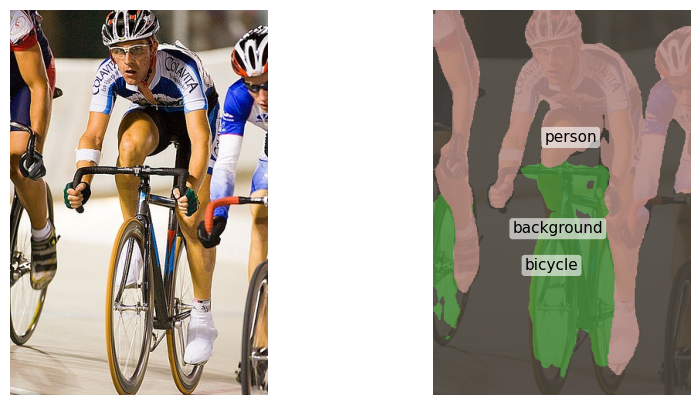

분할된 클래스 -> ['background', 'bicycle', 'person']


In [21]:
pred,vis=infer_one_image_pretrained(
    './data/VOCdevkit/VOC2012/JPEGImages/2007_000129.jpg',
    overlay=True,alpha=0.5
)

In [43]:
# 작업 준비
import os,time
from pathlib import Path
import numpy as np
from PIL import Image
from torch.utils.data import Dataset,DataLoader
from torchvision.transforms import functional as TF
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.transforms import InterpolationMode  # 추가

# 상수 정의
DATA_ROOT='./data/VOCdevkit'
SPLIT='VOC2012'
BATCH_SIZE=8
EPOCHS=5 # segmentation : 최소 100회
LR=0.005
MOMENTUM=0.9
WEIGHT_DECAY=0.0001
IMG_SIZE=512
N_CLASSES=21
IGNORE_INDEX=255
OUT_DIR='runs/fcn_scratch'
BEST_PATH=os.path.join(OUT_DIR,'best_m.pth')
os.makedirs(OUT_DIR,exist_ok=True)

In [47]:
# 데이터 수집(데이터 로드)
def make_transform(train):
    def _tfm(img,mask):
        img=TF.resize(img,(IMG_SIZE,IMG_SIZE))
        mask=TF.resize(mask,(IMG_SIZE,IMG_SIZE),interpolation=InterpolationMode.NEAREST)
        if train and torch.rand(1)<0.5:
            img=TF.hflip(img)
            mask=TF.hflip(mask)
        img=TF.to_tensor(img)
        img=TF.normalize(img,[0.485,0.456,0.406],[0.229,0.224,0.225])
        mask=torch.as_tensor(np.array(mask),dtype=torch.long)
        return img,mask
    return _tfm

class VOCDatasetTrain(Dataset):
    def __init__(self,root,split,image_set,transforms=None):
        super().__init__()
        base=Path(root)/split
        self.img_dir=base/'JPEGImages'
        self.mask_dir=base/'SegmentationClass'
        with open(base/'Imagesets'/'Segmentation'/f'{image_set}.txt') as f:
            self.ids=[x.strip() for x in f if x.strip()]
        self.tfm=transforms

    def __len__(self):
        return len(self.ids)
    
    def __getitem__(self,idx):
        id_=self.ids[idx]
        img=Image.open(self.img_dir/f'{id_}.jpg').convert('RGB')
        mask=Image.open(self.mask_dir/f'{id_}.png')
        if self.tfm:
            img,mask=self.tfm(img,mask)
        return img,mask

class VOCDatasetVal(VOCDatasetTrain):
    def __getitem__(self,idx):
        id_=self.ids[idx]
        img=Image.open(self.img_dir/f'{id_}.jpg').convert('RGB')
        mask=Image.open(self.mask_dir/f'{id_}.png')
        if self.tfm:
            img,mask=self.tfm(img,mask)
        return img,mask,id_

def get_loaders():
    tr_ds=VOCDatasetTrain(DATA_ROOT,SPLIT,'train',transforms=make_transform(train=True))
    val_ds=VOCDatasetVal(DATA_ROOT,SPLIT,'val',transforms=make_transform(train=False))

    tr_ds_loader=DataLoader(tr_ds,batch_size=BATCH_SIZE,shuffle=True)
    val_ds_loader=DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False)
    return tr_ds,val_ds,tr_ds_loader,val_ds_loader

In [48]:
# 색 정립 (배경/무시 정리)
PAL = np.array([
    [0,0,0],[128,0,0],[0,128,0],[128,128,0],[0,0,128],
    [128,0,128],[0,128,128],[128,128,128],[64,0,0],[192,0,0],
    [64,128,0],[192,128,0],[64,0,128],[192,0,128],[64,128,128],
    [192,128,128],[0,64,0],[128,64,0],[0,192,0],[128,192,0],[0,64,128]
], dtype=np.uint8)
BG_COLOR=np.array([50,50,50],dtype=np.uint8) # 배경(0) : 어두운 회색
IGNORE_COLOR=np.array([100,100,100],dtype=np.uint8) # 무시(255) : 밝은 회색

def _denorm(img):
    mean=torch.tensor([0.485,0.456,0.406])[:,None,None]
    std=torch.tensor([0.229,0.224,0.225])[:,None,None]
    return (img*std+mean).clamp(0,1)

def _colorize_mask(mask_np):
    out=PAL[np.clip(mask_np,0,len(PAL)-1)].copy()
    out[mask_np==0]=BG_COLOR
    out[mask_np==IGNORE_COLOR]=IGNORE_COLOR
    return out

@torch.no_grad()
def visualize_val_grid_random(epoch,model,val_ds,device,out_dir=OUT_DIR,samples=4):
    if len(val_ds)==0:
        print('검증 안함')
        return 
    os.makedirs(out_dir,exist_ok=True)
    idxs=np.random.choice(len(val_ds),size=min(samples,len(val_ds)),replace=False)
    imgs,gts=[],[]
    for idx in idxs:
        img,mask,_=val_ds[idx]
        imgs.append(img)
        gts.append(mask)
    batch=torch.stack(imgs).to(device)
    gts_np=[m.numpy() for m in gts]

    model.eval()
    out=model(batch)
    out=out['out'] if isinstance(out,dict) else out
    preds=out.argmax(1).detach().cpu().numpy()

    B=len(idxs)
    f,ax=plt.subplots(B,3,figsize=(12,3*B))

    if B==1:
        ax=np.expand_dims(ax,0)
    for i in range(B):
        img_np=_denorm(batch).detach().cpu().numpy().transpose(1,2,0)
        gt_rgb=_colorize_mask(gts_np[i],IGNORE_INDEX)
        pred_rgb=_colorize_mask(preds[i],IGNORE_INDEX)

        ax[i:0].imshow(img_np)
        ax[i:0].set_title('oj_img')
        ax[i:0].axis('off')

        ax[i:1].imshow(gt_rgb)
        ax[i:1].set_title('oj_mask')
        ax[i:1].axis('off')

        ax[i:2].imshow(pred_rgb)
        ax[i:2].set_title('pr_mask')
        ax[i:2].axis('off')

    plt.suptitle(f'val_(R)-Epoch{epoch}')
    save_path=os.path.join(out_dir,f'val_Epoch{epoch}.grid.png')
    plt.tight_layout()
    plt.savefig(save_path,dpi=150)
    plt.show()
    plt.close()
    print(f'기록 저장됨 -> {save_path}')

In [49]:
# 모델 학습
m=FCN8s(n_class=N_CLASSES)
# m=models.segmentation.fcn_resnet50(weights=None,weights_backbone=None,num_classes=N_CLASSES)
# m=models.segmentation.fcn_resnet50(weights=models.segmentation.FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1,num_classes=N_CLASSES)
m.to(device)

criterion=nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
opt=torch.optim.SGD(m.parameters(),lr=LR,momentum=MOMENTUM,weight_decay=WEIGHT_DECAY)

tr_ds,val_ds,tr_ds_loader,val_ds_loader=get_loaders()

@torch.no_grad()
def evaluate(model,loader,device):
    model.eval()
    num=0.0
    den=0.0
    for x,y in loader:
        img=x.to(device)
        mask=y.to(device)
        out=model(img)
        out=out['out'] if isinstance(out,dict) else out

        loss_map=F.cross_entropy(out,mask,ignore_index=IGNORE_INDEX,reduction='none')
        valid=(mask!=IGNORE_INDEX).float()
        num+=(loss_map*valid).sum().item()
        den+=valid.sum().item()
    return num/max(1.0,den)

best_loss=float('inf')

for epoch in range(1,EPOCHS+1):
    t0=time.time()
    m.train()
    r_num=0.0
    r_den=0.0
    for x,y in tr_ds_loader:
        img=x.to(device)
        mask=y.to(device)
        out=m(img)
        out=out['out'] if isinstance(out,dict) else out
        loss_map=F.cross_entropy(out,mask,ignore_index=IGNORE_INDEX,reduction='none')
        valid=(mask!=IGNORE_INDEX).float()
        loss=(loss_map*valid).sum()/valid.sum().clamp_min(1.0)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(),1.0)
        opt.step()

        r_num+=(loss_map*valid).sum().item()
        r_den+=valid.sum().item()
    tr_loss=r_num/max(1.0,r_den)
    val_loss=evaluate(m,val_ds_loader,device)
    dt=time.time()-t0
    print(f'Epoch : {epoch} / tr_loss : {tr_loss} / val_loss : {val_loss} / time : {dt}')

    if epoch%1==0:
        visualize_val_grid_random(epoch,m,val_ds_loader,device)

    if val_loss<best_loss-1e-8:
        best_loss=val_loss
        ckpt={'epoch':epoch,'m_state':m.state_dict(),'opt':opt.state_dict(),'val_loss':val_loss}
        torch.save(ckpt,BEST_PATH)
        print(f'[BEST] val_loss : {val_loss} -> {BEST_PATH} 저장함')

KeyboardInterrupt: 

## 원본 ↓

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
N_CLASSES=21
def _bilinear_kernel(in_ch, out_ch, k):
    factor = (k + 1) // 2
    center = factor - 1 if k % 2 == 1 else factor - 0.5
    og_y = torch.arange(k).reshape(-1, 1)
    og_x = torch.arange(k).reshape(1, -1)
    filt = (1 - torch.abs(og_y - center) / factor) * (1 - torch.abs(og_x - center) / factor)
    weight = torch.zeros((in_ch, out_ch, k, k))
    for i in range(in_ch):
        for j in range(out_ch):
            weight[i, j] = filt
    return weight

class FCN8s(nn.Module):
    def  __init__(self, n_class,use_interpolate=True):
        super().__init__()
        self.n_class=n_class
        self.use_interpolate=use_interpolate

        #인코더
        self.block1=nn.Sequential(
            nn.Conv2d(3,64,3,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64,64,3,padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2)#/2
        )
        self.block2=nn.Sequential(
            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128,128,3,padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2)#/4
        )
        self.block3=nn.Sequential(
            nn.Conv2d(128,256,3,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256,256,3,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256,256,3,padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2)#/8
        )
        self.block4=nn.Sequential(
            nn.Conv2d(256,512,3,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512,512,3,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512,512,3,padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2)#/16
        )
        self.block5=nn.Sequential(
            nn.Conv2d(512,512,3,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512,512,3,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512,512,3,padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2)#/32
        )
        self.conv6=nn.Sequential(
            nn.Conv2d(512,4096,3,padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.5)
        )
        self.conv7=nn.Sequential(
            nn.Conv2d(4096,4096,3,padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.5)
        )
        self.score_fr=nn.Conv2d(4096,n_class,kernel_size=1)
        self.score_pool4=nn.Conv2d(512,n_class,kernel_size=1)
        self.score_pool3=nn.Conv2d(256,n_class,kernel_size=1)
        
        #디코더
        self.upscore2=nn.ConvTranspose2d(n_class,n_class,kernel_size=4,stride=2,padding=1,bias=False)
        self.upscore_pool4=nn.ConvTranspose2d(n_class,n_class,kernel_size=4,stride=2,padding=1,bias=False)
        self.upscore8=nn.ConvTranspose2d(n_class,n_class,kernel_size=16,stride=8,padding=4,bias=False)

        self._init_weights()
        
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m,nn.Conv2d):
                nn.init.kaiming_normal_(m.weight,mode='fan_out',nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

        self.upscore2.weight.data.copy_(_bilinear_kernel(self.n_class,self.n_class,4))
        self.upscore_pool4.weight.data.copy_(_bilinear_kernel(self.n_class,self.n_class,4))
        self.upscore8.weight.data.copy_(_bilinear_kernel(self.n_class,self.n_class,16))

    def forward(self,x):
        H,W=x.shape[-2:]

        #인코더층
        h=self.block1(x)
        h=self.block2(h)
        pool3 = self.block3(h)
        pool4 = self.block4(pool3)
        pool5 = self.block5(pool4)
        
        #분류층
        h=self.conv6(pool5)
        h=self.conv7(h)
        score_fr=self.score_fr(h) #/32
        
        #디코더층1 /16
        upscore2=self.upscore2(score_fr)#/16
        score_pool4=self.score_pool4(pool4)#/16
        fuse_pool4=upscore2+score_pool4
        
        #디코더층2 /8
        upscore_pool4 = self.upscore_pool4(fuse_pool4)#/8
        score_pool3 = self.score_pool3(pool3)#/8
        fuse_pool3 = upscore_pool4+score_pool3
        
        #디코더층3 /1
        out = self.upscore8(fuse_pool3) #(B,C,H,W)

        # 해상도 오차 조정(입력 크기 차이성)
        if self.use_interpolate and (out.shape[-2:] != (H, W)):
            out = F.interpolate(out, size=(H, W), mode="bilinear", align_corners=False)
        
        return {'out':out}   

In [ ]:
m=FCN8s(n_class=N_CLASSES)

In [ ]:
from torchvision import models
m1=models.segmentation.fcn_resnet50(
    weights=None,   #랜덤 초기화,
    weights_backbone=None,#백본가중치 랜덤 초기화 
    num_classes=N_CLASSES
)

In [ ]:
weights = models.segmentation.FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
m2=models.segmentation.fcn_resnet50(weights=weights,num_classes=N_CLASSES)

In [ ]:
!pip install matplotlib

Looking in indexes: https://mirror.kakao.com/pypi/simple


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
m2

FCN(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequenti

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import functional as TF
import os

IMG_SIZE=512
IGNORE_INDEX = 255
VOC_CLASSES=[
    "background",
    "aeroplane","bicycle","bird","boat",
    "bottle","bus","car","cat","chair",
    "cow","diningtable","dog","horse","motorbike",
    "person","pottedplant","sheep","sofa","train","tvmonitor"
]
PAL = np.array([
    [0,0,0],[128,0,0],[0,128,0],[128,128,0],[0,0,128],
    [128,0,128],[0,128,128],[128,128,128],[64,0,0],[192,0,0],
    [64,128,0],[192,128,0],[64,0,128],[192,0,128],[64,128,128],
    [192,128,128],[0,64,0],[128,64,0],[0,192,0],[128,192,0],[0,64,128]
], dtype=np.uint8)


def denorm(img):
    mean=torch.tensor([0.485, 0.456, 0.406],device=img.device)[:,None,None]
    std=torch.tensor([0.229, 0.224, 0.225],device=img.device)[:,None,None]
    return (img*std+mean).clamp(0,1)

def colorize_mask(mask_np):
    m=mask_np.copy()
    m[m == IGNORE_INDEX]==0
    return PAL[m]

def preprocess_image_for_infer(img_path):
    img=Image.open(img_path).convert('RGB')
    img_r=TF.resize(img,(IMG_SIZE,IMG_SIZE))
    t=TF.to_tensor(img_r)
    t=TF.normalize(t,[0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
    return img,t.unsqueeze(0)
def annotate_classes_on_segments(ax,pred_mask_resized,classes,ignore_index=255,bg_color='white'):
    uniq=np.unique(pred_mask_resized)
    uniq=uniq[uniq != ignore_index]
    for cls_id in uniq:
        if not (0 <= cls_id < len(classes)):
            continue
        ys,xs=np.where(pred_mask_resized==cls_id)
        if ys.size==0:
            continue
        cy,cx=float(ys.mean()),float(xs.mean())
        ax.text(cx,cy,classes[cls_id],ha='center',va='center',fontsize=11,color='black',
                bbox=dict(facecolor=bg_color,alpha=0.6,edgecolor='none',boxstyle='round,pad=0.2')
               )
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
@torch.no_grad()
def infer_one_image_pretrained(img_path,save_path=None,overlay=True,alpha=0.6):
    weights = models.segmentation.FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
    m=models.segmentation.fcn_resnet50(weights=weights,num_classes=N_CLASSES).to(device)
    m.eval()

    pil_oj,t=preprocess_image_for_infer(img_path)
    t=t.to(device)
    out=m(t)['out'] #(1,21,512,512)
    pred_512 = out.argmax(1)[0].cpu().numpy()#(512,512)
    vis_mask=colorize_mask(pred_512) #(512,512,3)
    if overlay:
        den=(denorm(t[0]).cpu().numpy().transpose(1,2,0)*255).astype(np.uint8)
        vis_512=(den*(1-alpha)+vis_mask*alpha).astype(np.uint8)
    else:
        vis_512=vis_mask
    out_vis_pil=Image.fromarray(vis_512).resize(pil_oj.size,resample=Image.NEAREST)
    pred_orig=np.array(Image.fromarray(pred_512.astype(np.uint8)).resize(pil_oj.size,resample=Image.NEAREST))

    plt.figure(figsize=(10,5))
    ax1=plt.subplot(1,2,1)
    ax1.imshow(pil_oj)
    ax1.axis('off')
    ax2=plt.subplot(1,2,2)
    ax2.imshow(out_vis_pil)
    ax2.axis('off')
    annotate_classes_on_segments(ax2,pred_orig,VOC_CLASSES,IGNORE_INDEX)
    plt.show()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path),exist_ok=True)
        save_path.save(save_path)
        print(f"저장완료{save_path}")
    uniq=np.unique(pred_orig)
    uniq=uniq[uniq!=IGNORE_INDEX]
    detectde=[VOC_CLASSES[i] for i in uniq if 0<= i < len(VOC_CLASSES)]
    print(f"분할된 클래스{detectde}")

    return pred_orig,out_vis_pil

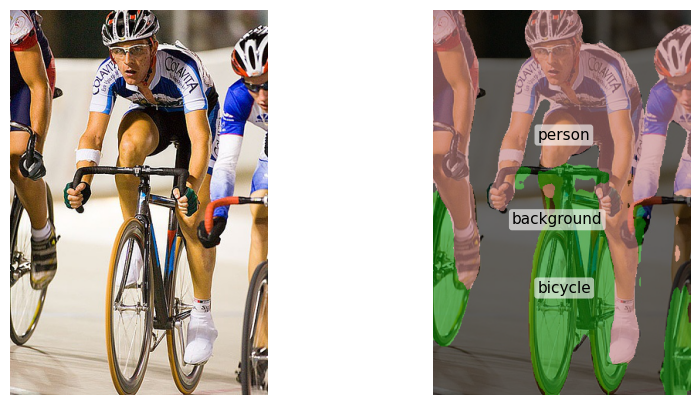

분할된 클래스['background', 'bicycle', 'person']


In [ ]:
pred,vis=infer_one_image_pretrained(
    "./data/VOCdevkit/VOC2012/JPEGImages/2007_000129.jpg",
    overlay=True,alpha=0.6
)

In [ ]:
#작업 준비
import os, time
from pathlib import Path
import numpy as np
from PIL import Image

from torch.utils.data import Dataset,DataLoader
from torchvision.transforms import functional as TF

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

#상수정의
DATA_ROOT='./data/VOCdevkit'
SPLIT='VOC2012'
BATCH_SIZE=8
EPOCHS=5
LR=0.005
MOMENTUM=0.9
WEIGHT_DECAY=0.0001

IMG_SIZE=512
N_CLASSES=21
IGNORE_INDEX=255

OUT_DIR='runs/fcn_scratch'
BEST_PATH=os.path.join(OUT_DIR,'best_m.pth')
os.makedirs(OUT_DIR,exist_ok=True)

In [ ]:
#데이터 수집(데이터 로드)
def make_transform(train):
    def _tfm(img,mask):
        img= TF.resize(img,(IMG_SIZE,IMG_SIZE))
        mask= TF.resize(mask,(IMG_SIZE,IMG_SIZE),interpolation=TF.InterpolationMode.NEAREST)
        if train and torch.rand(1)<0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)
        img = TF.to_tensor(img)
        img = TF.normalize(img, [0.485,0.456,0.406], [0.229,0.224,0.225])
        mask=torch.as_tensor(np.array(mask),dtype=torch.long)
        return img,mask
    return _tfm
class VOCDatasetTrain(Dataset):
    def __init__(self,root,split,image_set,transforms=None):
        base=Path(root)/split
        self.img_dir=base/'JPEGImages'
        self.mask_dir=base/'SegmentationClass'
        with open(base/'ImageSets'/'Segmentation'/f'{image_set}.txt') as f:
            self.ids= [x.strip() for x in f if x.strip()]
        self.tfm=transforms
    def __len__(self):
        return len(self.ids)
    def __getitem__(self,idx):
        id_ =self.ids[idx]
        img=Image.open(self.img_dir/f'{id_}.jpg').convert('RGB')
        mask=Image.open(self.mask_dir/f'{id_}.png')
        if self.tfm:
            img,mask=self.tfm(img,mask)
        return img,mask

class VOCDatasetVal(VOCDatasetTrain):
    def __getitem__(self,idx):
        id_ =self.ids[idx]
        img=Image.open(self.img_dir/f'{id_}.jpg').convert('RGB')
        mask=Image.open(self.mask_dir/f'{id_}.png')
        if self.tfm:
            img,mask=self.tfm(img,mask)
        return img,mask,id_

def get_loaders():
    tr_ds=VOCDatasetTrain(DATA_ROOT,SPLIT,'train',transforms=make_transform(train=True))
    val_ds=VOCDatasetVal(DATA_ROOT,SPLIT,'val',transforms=make_transform(train=False))
    
    tr_ds_loader = DataLoader(tr_ds,batch_size=BATCH_SIZE,shuffle=True)
    val_ds_loader = DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False)
    #tr_ds_loader = DataLoader(tr_ds,batch_size=BATCH_SIZE,shuffle=True,num_workers=4, pin_memory=True)
    #val_ds_loader = DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False,num_workers=4, pin_memory=True)
    return tr_ds,val_ds,tr_ds_loader,val_ds_loader 

In [ ]:
#색 정립 (배경/무시 정리)

PAL = np.array([
    [0,0,0],[128,0,0],[0,128,0],[128,128,0],[0,0,128],
    [128,0,128],[0,128,128],[128,128,128],[64,0,0],[192,0,0],
    [64,128,0],[192,128,0],[64,0,128],[192,0,128],[64,128,128],
    [192,128,128],[0,64,0],[128,64,0],[0,192,0],[128,192,0],[0,64,128]
], dtype=np.uint8)
BG_COLOR=np.array([50,50,50],dtype=np.uint8)        #배경(0): 어두운 회색
IGNORE_COLOR=np.array([100,100,100],dtype=np.uint8) #무시(255): 밝은 회색

def _denorm(img):
    mean=torch.tensor([0.485, 0.456, 0.406],device=img.device)[:,None,None]
    std=torch.tensor([0.229, 0.224, 0.225],device=img.device)[:,None,None]
    return (img*std+mean).clamp(0,1)
    
def _colorize_mask(mask_np,ignore_idx):
    out=PAL[np.clip(mask_np,0,len(PAL)-1)].copy()
    out[mask_np == 0]=BG_COLOR
    out[mask_np == ignore_idx]=IGNORE_COLOR
    return out

    
@torch.no_grad()
def visualize_val_grid_random(epoch,model,val_ds,device,out_dir=OUT_DIR, samples=4):
    if len(val_ds)==0:
        print("검증 안함")
        return 
    os.makedirs(out_dir,exist_ok=True)
    
    idxs = np.random.choice(len(val_ds),size=min(samples,len(val_ds)),replace=False)
    imgs,gts=[],[]
    for idx in idxs:
        img,mask,_ = val_ds[idx]
        imgs.append(img)
        gts.append(mask)
    batch = torch.stack(imgs).to(device)
    gts_np = [m.numpy() for m in gts]

    model.eval()
    out=model(batch)
    out=out['out'] if isinstance(out, dict) else out
    preds=out.argmax(1).detach().cpu().numpy()

    B=len(idxs)
    f,ax=plt.subplots(B,3,figsize=(12,3*B))

    if B==1:
        ax=np.expand_dims(ax,0)
    for i in range(B):
        img_np   = _denorm(batch[i]).detach().cpu().numpy().transpose(1, 2, 0)
        gt_rgb = _colorize_mask(gts_np[i],IGNORE_INDEX)
        pred_rgb = _colorize_mask(preds[i],IGNORE_INDEX)

        ax[i,0].imshow(img_np)
        ax[i,0].set_title("oj_img")
        ax[i,0].axis('off')
        
        ax[i,1].imshow(gt_rgb)
        ax[i,1].set_title("oj_mask")
        ax[i,1].axis('off')
        
        ax[i,2].imshow(pred_rgb)
        ax[i,2].set_title("pr_mask")
        ax[i,2].axis('off')
    plt.suptitle(f'val_(R)-Epoch{epoch}')
    save_path=os.path.join(out_dir,f'val_Epoch{epoch}.grid.png')
    plt.tight_layout()
    plt.savefig(save_path,dpi=150)
    plt.show()
    plt.close()
    print(f"기록 저장됨{save_path}")

Epoch1/5 tr_loss1.663286626476492,val_loss1.3587259266882954,time307.77250814437866


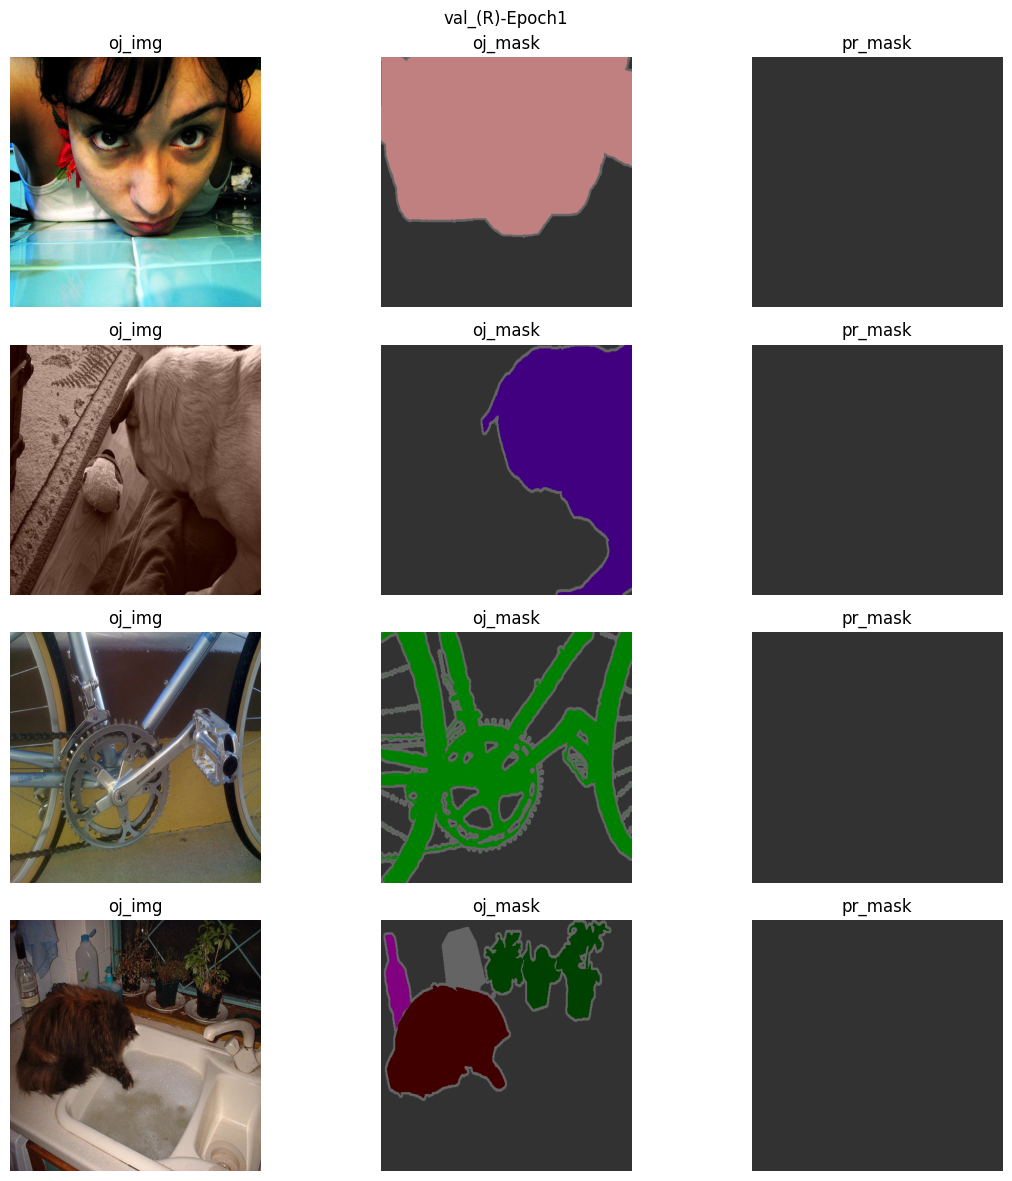

기록 저장됨runs/fcn_scratch/val_Epoch1.grid.png
[BEST] val_loss:1.3587259266882954 runs/fcn_scratch/best_m.pth저장 함



KeyboardInterrupt



In [ ]:
#모델 학습
m=FCN8s(n_class=N_CLASSES)
#m=models.segmentation.fcn_resnet50(weights=None,weights_backbone=None,num_classes=N_CLASSES)
#m=models.segmentation.fcn_resnet50(weights=models.segmentation.FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1,num_classes=N_CLASSES)
m.to(device)

criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
opt= torch.optim.SGD(m.parameters(),lr=LR,momentum=MOMENTUM,weight_decay=WEIGHT_DECAY)

tr_ds,val_ds,tr_ds_loader,val_ds_loader=get_loaders()

@torch.no_grad()
def evaluate(model,loader,device):
    model.eval()
    num=0.0
    den=0.0
    for x,y,id_ in loader:
        img=x.to(device)
        mask=y.to(device)
        out=model(img)
        out = out['out'] if isinstance(out, dict) else out

        loss_map = F.cross_entropy(out,mask,ignore_index=IGNORE_INDEX,reduction='none')
        valid = (mask != IGNORE_INDEX).float()
        num += (loss_map*valid).sum().item()
        den += valid.sum().item()
    return num/max(1.0,den)
    
torch.backends.cudnn.benchmark = True
best_loss=float('inf')
for epoch in range(1,EPOCHS+1):
    t0=time.time()
    m.train()
    r_num=0.0
    r_den=0.0
    for x,y in tr_ds_loader:
        img=x.to(device)
        mask=y.to(device)
        out=m(img)
        out = out['out'] if isinstance(out, dict) else out
        loss_map = F.cross_entropy(out,mask,ignore_index=IGNORE_INDEX,reduction='none')
        valid = (mask != IGNORE_INDEX).float()
        loss = (loss_map*valid).sum()/valid.sum().clamp_min(1.0)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(),1.0)
        opt.step()

        r_num += (loss_map*valid).sum().item()
        r_den += valid.sum().item()
    tr_loss=r_num/max(1.0,r_den)
    val_loss=evaluate(m,val_ds_loader,device)
    dt=time.time() - t0
    print(f'Epoch{epoch}/{EPOCHS} tr_loss{tr_loss},val_loss{val_loss},time{dt}')

    if epoch %1 ==0:
        visualize_val_grid_random(epoch,m,val_ds,device)

    if val_loss < best_loss - 1e-8:
        best_loss=val_loss
        ckpt ={
            'epoch':epoch,
            'm_state':m.state_dict(),
            'opt':opt.state_dict(),
            'val_loss':val_loss
        }
        torch.save(ckpt,BEST_PATH)
        print(f"[BEST] val_loss:{val_loss} {BEST_PATH}저장 함")
        

Epoch1/5 tr_loss1.623546781940363,val_loss1.373972071716211,time784.1232600212097


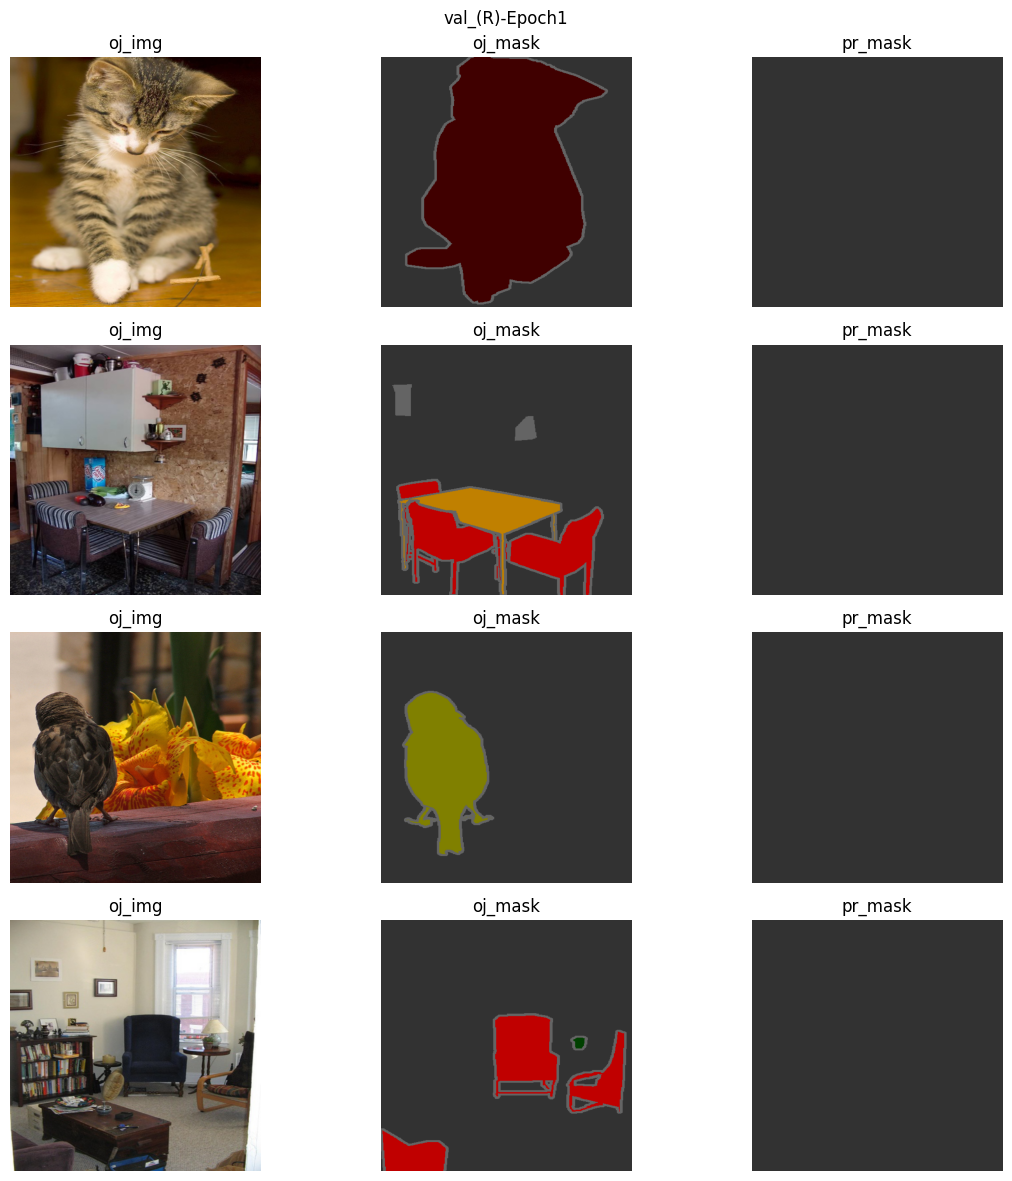

기록 저장됨runs/fcn_scratch/val_Epoch1.grid.png
[BEST] val_loss:1.373972071716211 runs/fcn_scratch/best_m.pth저장 함
Epoch2/5 tr_loss1.38130027461985,val_loss1.2890245978891028,time731.0046260356903


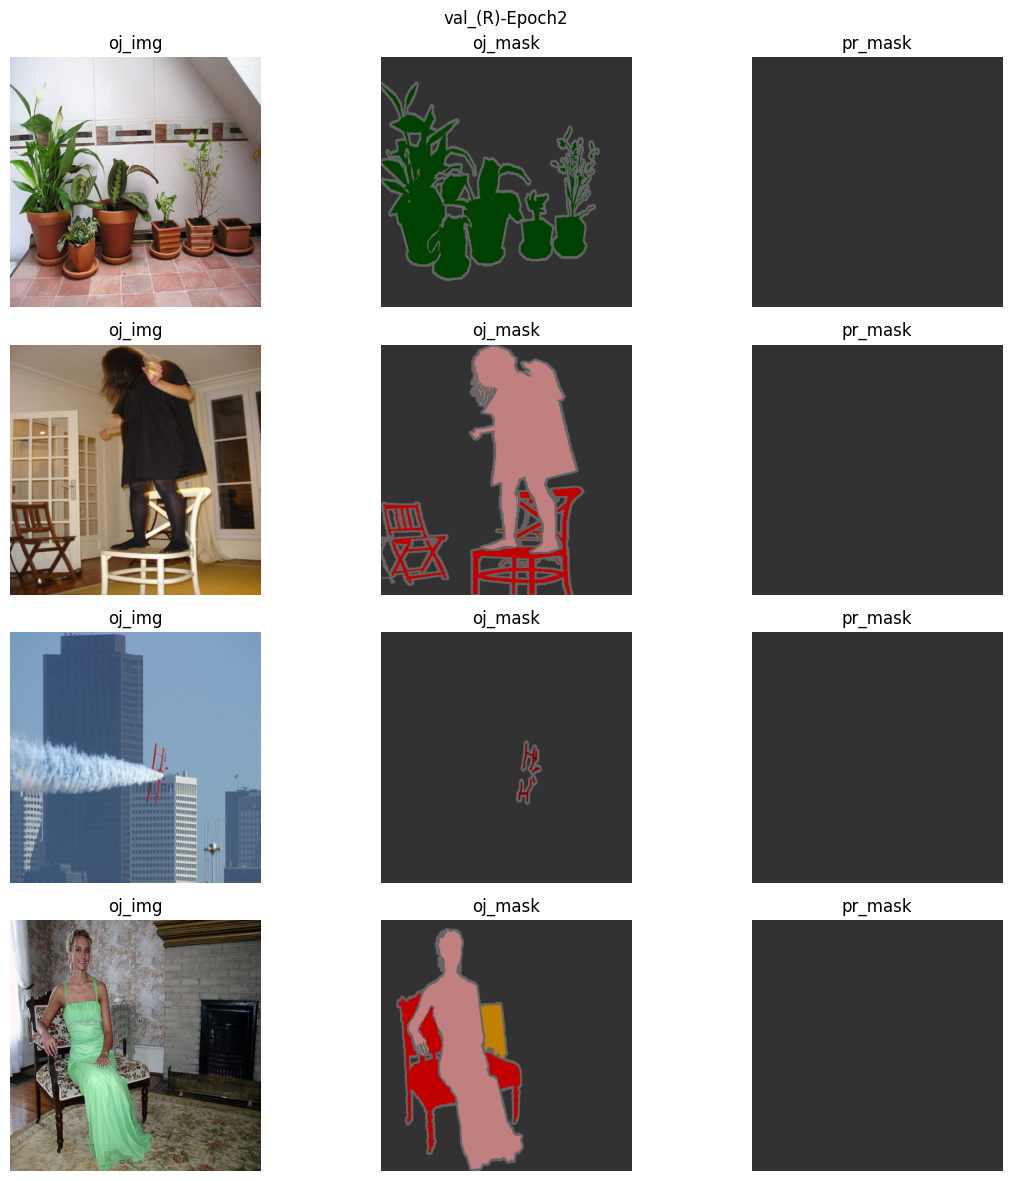

기록 저장됨runs/fcn_scratch/val_Epoch2.grid.png
[BEST] val_loss:1.2890245978891028 runs/fcn_scratch/best_m.pth저장 함
Epoch3/5 tr_loss1.38427837184986,val_loss1.2804859684949959,time713.9306757450104


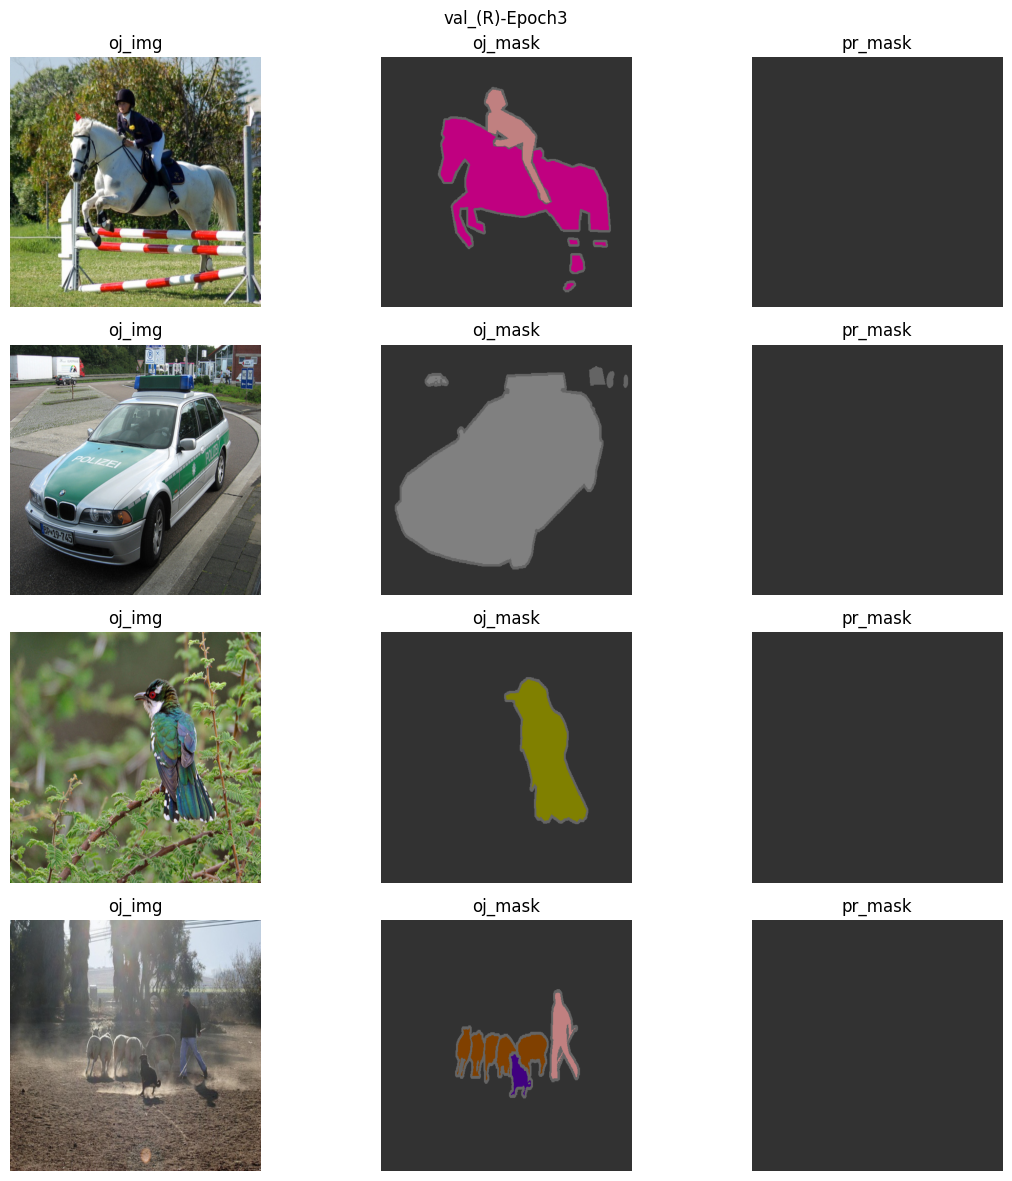

기록 저장됨runs/fcn_scratch/val_Epoch3.grid.png
[BEST] val_loss:1.2804859684949959 runs/fcn_scratch/best_m.pth저장 함
Epoch4/5 tr_loss1.3663852055556591,val_loss1.2702015585752162,time738.7488474845886


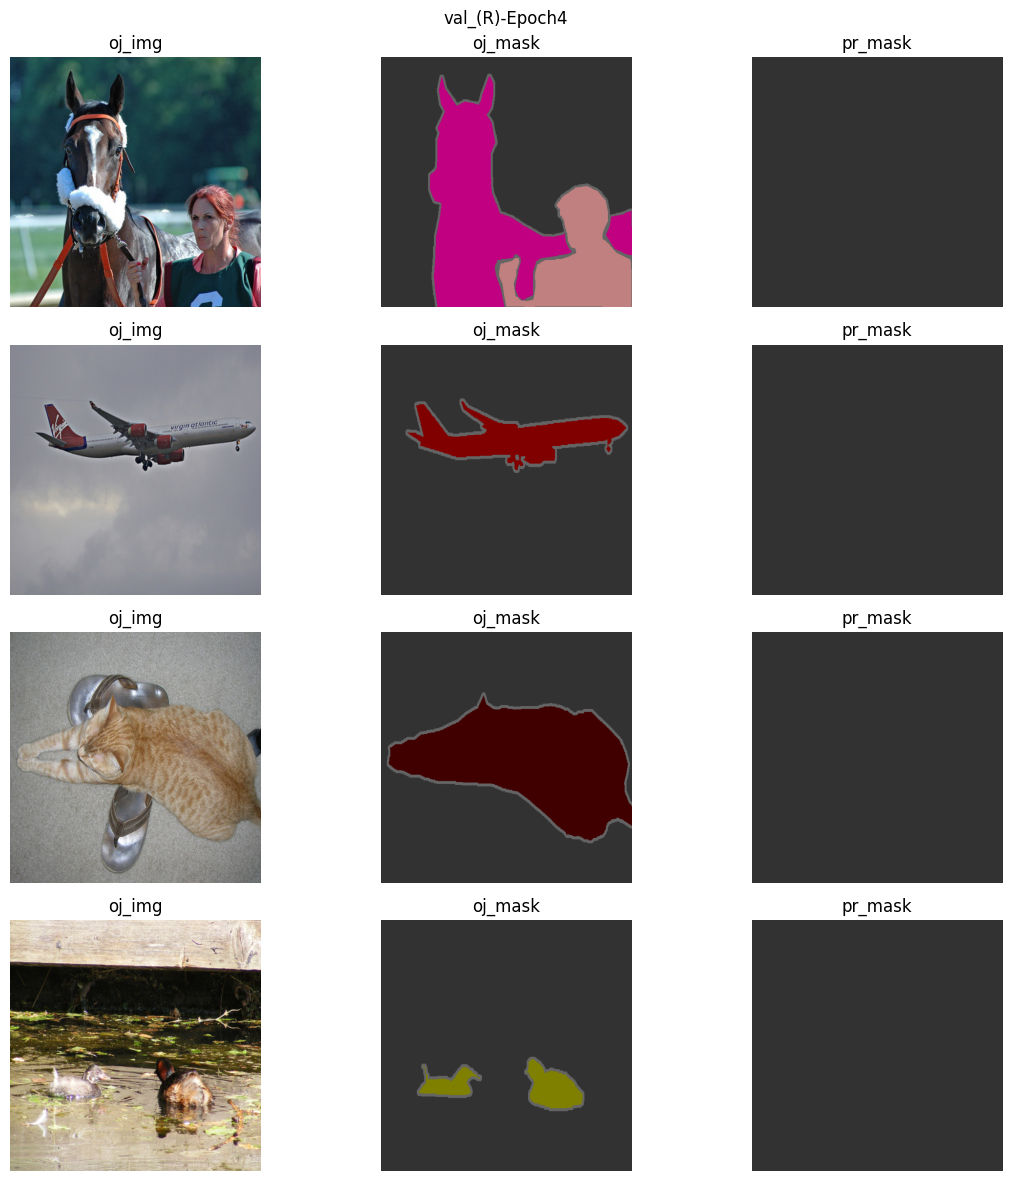

기록 저장됨runs/fcn_scratch/val_Epoch4.grid.png
[BEST] val_loss:1.2702015585752162 runs/fcn_scratch/best_m.pth저장 함
Epoch5/5 tr_loss1.351070894334439,val_loss1.5288280055947716,time732.1351037025452


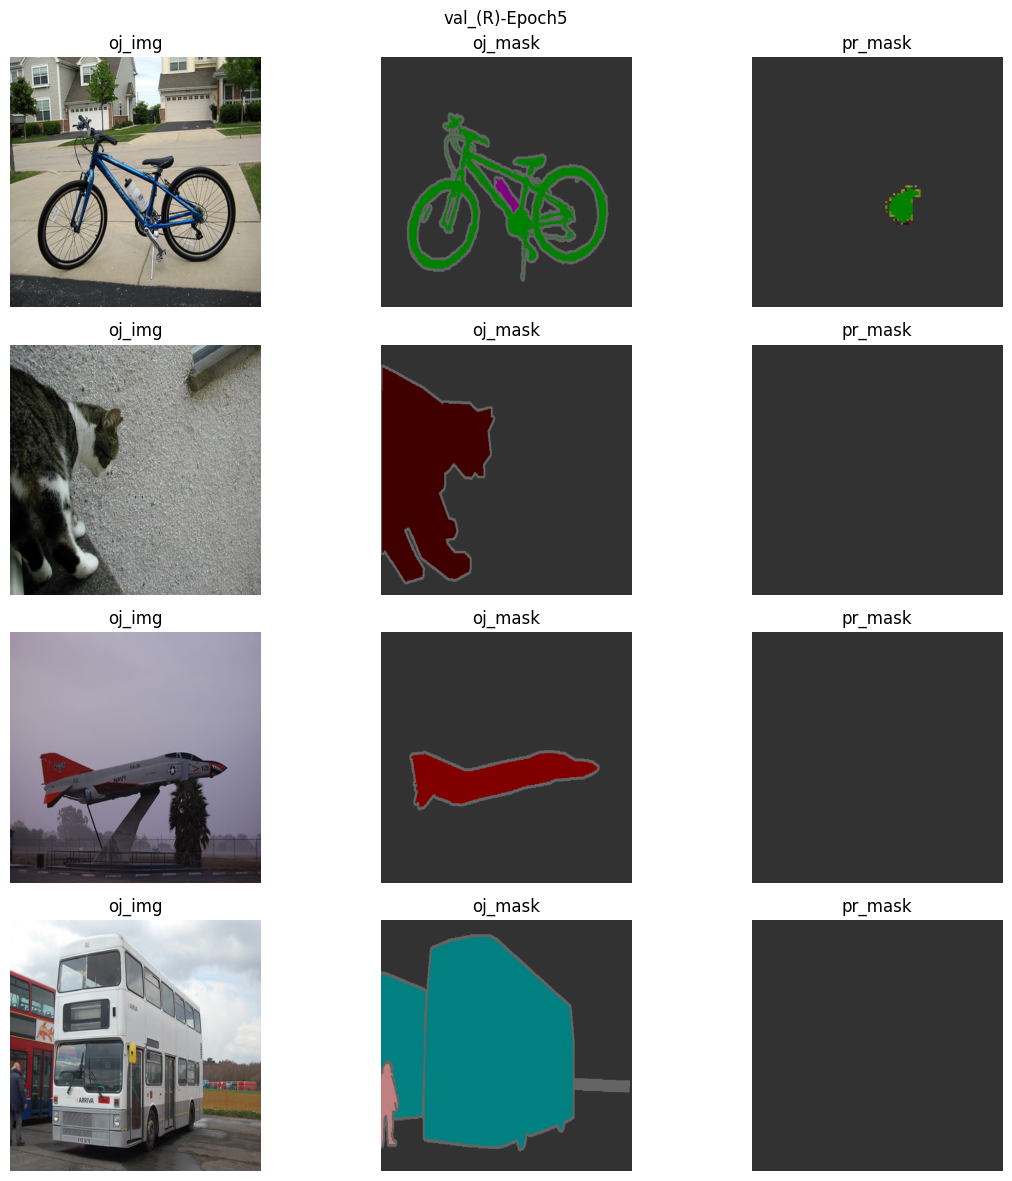

기록 저장됨runs/fcn_scratch/val_Epoch5.grid.png


In [ ]:
# in GPU
#모델 학습
m=FCN8s(n_class=N_CLASSES)
#m=models.segmentation.fcn_resnet50(weights=None,weights_backbone=None,num_classes=N_CLASSES)
#m=models.segmentation.fcn_resnet50(weights=models.segmentation.FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1,num_classes=N_CLASSES)
m.to(device)

criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
opt= torch.optim.SGD(m.parameters(),lr=LR,momentum=MOMENTUM,weight_decay=WEIGHT_DECAY)

tr_ds,val_ds,tr_ds_loader,val_ds_loader=get_loaders()

@torch.no_grad()
def evaluate(model,loader,device):
    model.eval()
    num=0.0
    den=0.0
    for x,y,id_ in loader:
        img=x.to(device)
        mask=y.to(device)
        out=model(img)
        out = out['out'] if isinstance(out, dict) else out

        loss_map = F.cross_entropy(out,mask,ignore_index=IGNORE_INDEX,reduction='none')
        valid = (mask != IGNORE_INDEX).float()
        num += (loss_map*valid).sum().item()
        den += valid.sum().item()
    return num/max(1.0,den)
    
torch.backends.cudnn.benchmark = True
best_loss=float('inf')
for epoch in range(1,EPOCHS+1):
    t0=time.time()
    m.train()
    r_num=0.0
    r_den=0.0
    for x,y in tr_ds_loader:
        img=x.to(device)
        mask=y.to(device)
        out=m(img)
        out = out['out'] if isinstance(out, dict) else out
        loss_map = F.cross_entropy(out,mask,ignore_index=IGNORE_INDEX,reduction='none')
        valid = (mask != IGNORE_INDEX).float()
        loss = (loss_map*valid).sum()/valid.sum().clamp_min(1.0)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(),1.0)
        opt.step()

        r_num += (loss_map*valid).sum().item()
        r_den += valid.sum().item()
    tr_loss=r_num/max(1.0,r_den)
    val_loss=evaluate(m,val_ds_loader,device)
    dt=time.time() - t0
    print(f'Epoch{epoch}/{EPOCHS} tr_loss{tr_loss},val_loss{val_loss},time{dt}')

    if epoch %1 ==0:
        visualize_val_grid_random(epoch,m,val_ds,device)

    if val_loss < best_loss - 1e-8:
        best_loss=val_loss
        ckpt ={
            'epoch':epoch,
            'm_state':m.state_dict(),
            'opt':opt.state_dict(),
            'val_loss':val_loss
        }
        torch.save(ckpt,BEST_PATH)
        print(f"[BEST] val_loss:{val_loss} {BEST_PATH}저장 함")
        